In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(
    '/content/Comment Toxicity Detection train.csv',
    on_bad_lines='skip'
)

In [3]:
one = df.copy()

In [4]:
one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [5]:
one.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [6]:
one.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
import re

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove newline
    text = text.replace('\n', ' ')

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text
one['comment_text'] =one['comment_text'].apply(clean_text)

In [8]:
one.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,explanation why the edits made under my userna...,0,0,0,0,0,0
1,000103f0d9cfb60f,daww he matches this background colour im seem...,0,0,0,0,0,0
2,000113f07ec002fd,hey man im really not trying to edit war its j...,0,0,0,0,0,0
3,0001b41b1c6bb37e,more i cant make any real suggestions on impro...,0,0,0,0,0,0
4,0001d958c54c6e35,you sir are my hero any chance you remember wh...,0,0,0,0,0,0


In [9]:
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

one['comment_text'] = one['comment_text'].apply(remove_stopwords)

one.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,explanation edits made username hardcore metal...,0,0,0,0,0,0
1,000103f0d9cfb60f,daww matches background colour im seemingly st...,0,0,0,0,0,0
2,000113f07ec002fd,hey man im really trying edit war guy constant...,0,0,0,0,0,0
3,0001b41b1c6bb37e,cant make real suggestions improvement wondere...,0,0,0,0,0,0
4,0001d958c54c6e35,sir hero chance remember page thats,0,0,0,0,0,0


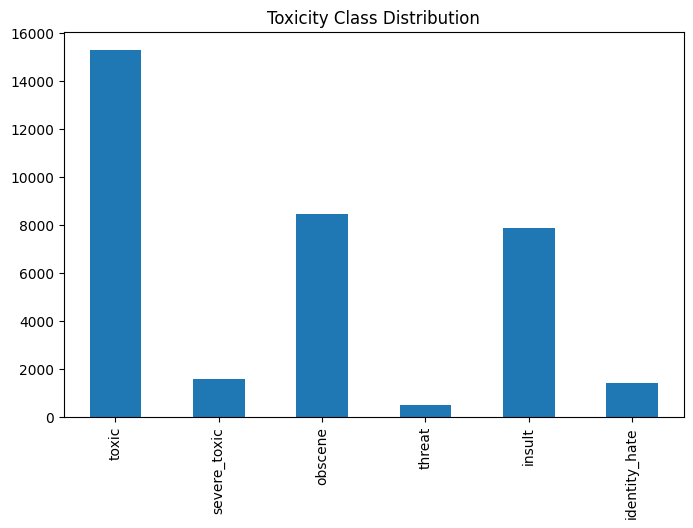

In [10]:
import matplotlib.pyplot as plt

labels = [
    'toxic',
    'severe_toxic',
    'obscene',
    'threat',
    'insult',
    'identity_hate'
]

one[labels].sum().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Toxicity Class Distribution")
plt.show()

In [11]:
one['comment_text'].unique()

array(['explanation edits made username hardcore metallica fan reverted werent vandalisms closure gas voted new york dolls fac please dont remove template talk page since im retired',
       'daww matches background colour im seemingly stuck thanks talk january utc',
       'hey man im really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info',
       ...,
       'spitzer umm theres actual article prostitution ring crunch captain',
       'looks like actually put speedy first version deleted look',
       'really dont think understand came idea bad right away kind community goes bad ideas go away instead helping rewrite'],
      dtype=object)

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [13]:
tokenizer = Tokenizer(num_words=5000)

In [14]:
X = one['comment_text']

y = one[
    [
        'toxic',
        'severe_toxic',
        'obscene',
        'threat',
        'insult',
        'identity_hate'
    ]
]

In [15]:
tokenizer.fit_on_texts(X)

In [16]:
X_seq = tokenizer.texts_to_sequences(X)
X[0]

X_seq[0]

[523,
 44,
 47,
 513,
 4394,
 920,
 208,
 1884,
 2479,
 2633,
 37,
 1009,
 2665,
 5,
 9,
 136,
 300,
 4,
 2,
 58,
 13,
 3210]

In [17]:
lengths = [len(seq) for seq in X_seq]
print(max(lengths))
print(min(lengths))

1250
0


In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [19]:
import numpy as np


lengths = [len(seq) for seq in X_seq]

print(np.percentile(lengths,90))

print(np.percentile(lengths,95))

print(np.percentile(lengths,99))

62.0
95.0
230.29999999998836


In [20]:

X_pad = pad_sequences(X_seq, maxlen=200)

print(X_pad.shape)

(159571, 200)


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(127656, 200)
(31915, 200)
(127656, 6)
(31915, 6)


In [23]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(31915, 6)

In [24]:
import torch.nn as nn


In [25]:

len(tokenizer.word_index)

223813

In [26]:
#save tokenizer
import pickle

with open(
    "tokenizer.pkl",
    "wb"
) as f:

    pickle.dump(
        tokenizer,
        f
    )

#rnn

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import Precision
from tensorflow.keras.metrics import Recall


rnn_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=200
    ),

    SimpleRNN(
        128,
        return_sequences=True
    ),

    Dropout(0.3),

    SimpleRNN(
        64
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        6,
        activation='sigmoid'
    )

])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(),
        Recall()
    ]
)
rnn_model.build(input_shape=(None, 200))
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 200, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 691,686 (2.64 MB)

 Trainable params: 691,686 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
#train rnn
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/20
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 129s 32ms/step - accuracy: 0.9942 - loss: 0.0589 - precision: 0.8015 - recall: 0.5905 - val_accuracy: 0.9941 - val_loss: 0.0634 - val_precision: 0.8146 - val_recall: 0.5714
Epoch 2/20
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 129s 32ms/step - accuracy: 0.9941 - loss: 0.0573 - precision: 0.8110 - recall: 0.5973 - val_accuracy: 0.9941 - val_loss: 0.0622 - val_precision: 0.8071 - val_recall: 0.5807
Epoch 3/20
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 129s 32ms/step - accuracy: 0.9942 - loss: 0.0581 - precision: 0.8135 - recall: 0.5932 - val_accuracy: 0.9941 - val_loss: 0.0607 - val_precision: 0.8092 - val_recall: 0.5749
Epoch 4/20
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 131s 33ms/step - accuracy: 0.9942 - loss: 0.0555 - precision: 0.8175 - recall: 0.6060 - val_accuracy: 0.9941 - val_loss: 0.0593 - val_precision: 0.8028 - val_recall: 0.5895
Epoch 5/20
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 128s 32ms/step - accuracy: 0.9941 - loss: 0.0562 - precision: 0.8070 - recall: 0.6087 - val_accura

In [40]:
rnn_loss, rnn_acc, rnn_precision, rnn_recall = rnn_model.evaluate(
    X_test,
    y_test
)

print("RNN Loss :", rnn_loss)
print("RNN Accuracy :", rnn_acc)
print("RNN Precision :", rnn_precision)
print("RNN Recall :", rnn_recall)

998/998 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9941 - loss: 0.0593 - precision: 0.8028 - recall: 0.5895
RNN Loss : 0.05930081754922867
RNN Accuracy : 0.9941093325614929
RNN Precision : 0.8028494119644165
RNN Recall : 0.5894826054573059


In [41]:
#rnn prediction
rnn_pred = rnn_model.predict(X_test)

rnn_pred = (
    rnn_pred > 0.5
).astype(int)

998/998 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step


In [42]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rnn_pred,
        target_names=[
            'toxic',
            'severe_toxic',
            'obscene',
            'threat',
            'insult',
            'identity_hate'
        ]
    )
)

               precision    recall  f1-score   support

        toxic       0.81      0.69      0.74      3056
 severe_toxic       0.00      0.00      0.00       321
      obscene       0.85      0.70      0.77      1715
       threat       0.00      0.00      0.00        74
       insult       0.74      0.53      0.62      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.80      0.59      0.68      7074
    macro avg       0.40      0.32      0.35      7074
 weighted avg       0.72      0.59      0.65      7074
  samples avg       0.06      0.05      0.05      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [43]:
from sklearn.metrics import f1_score

rnn_f1 = f1_score(
    y_test,
    rnn_pred,
    average='macro'
)

print("RNN Macro F1 Score :", rnn_f1)

RNN Macro F1 Score : 0.3547931959331257


In [44]:
from sklearn.metrics import multilabel_confusion_matrix

rnn_cm = multilabel_confusion_matrix(
    y_test,
    rnn_pred
)

print(rnn_cm)

[[[28348   511]
  [  939  2117]]

 [[31594     0]
  [  321     0]]

 [[29989   211]
  [  515  1200]]

 [[31841     0]
  [   74     0]]

 [[29999   302]
  [  761   853]]

 [[31621     0]
  [  294     0]]]


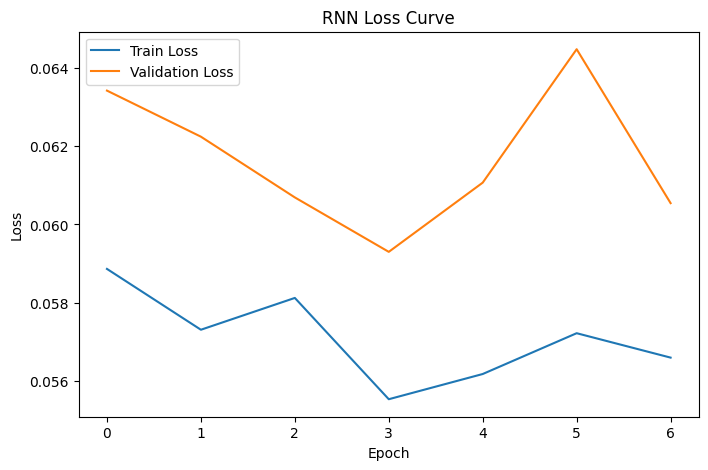

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_rnn.history['val_loss'],
    label='Validation Loss'
)

plt.title("RNN Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

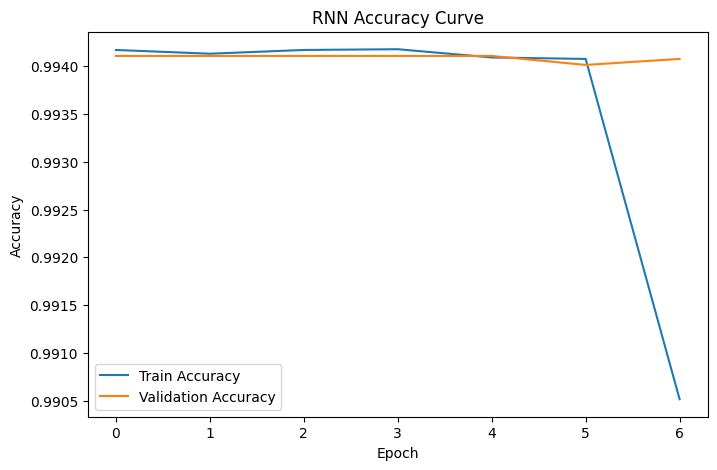

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    history_rnn.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_rnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("RNN Accuracy Curve")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [35]:
#bilstm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.layers import Dropout

bilstm_model = Sequential([

    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=200
    ),

    Bidirectional(
        LSTM(
            128,
            return_sequences=True
        )
    ),

    Dropout(0.3),

    Bidirectional(
        LSTM(
            64
        )
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        6,
        activation='sigmoid'
    )

])

bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        Precision(),
        Recall()
    ]
)
bilstm_model.build(input_shape=(None, 200))
bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,078,054 (4.11 MB)

 Trainable params: 1,078,054 (4.11 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#trainbilstm
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 156s 37ms/step - accuracy: 0.9883 - loss: 0.0683 - precision_1: 0.7943 - recall_1: 0.5394 - val_accuracy: 0.9941 - val_loss: 0.0560 - val_precision_1: 0.7985 - val_recall_1: 0.6391
Epoch 2/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 144s 36ms/step - accuracy: 0.9912 - loss: 0.0542 - precision_1: 0.8175 - recall_1: 0.6101 - val_accuracy: 0.9941 - val_loss: 0.0545 - val_precision_1: 0.8185 - val_recall_1: 0.6316
Epoch 3/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 145s 36ms/step - accuracy: 0.9828 - loss: 0.0509 - precision_1: 0.8234 - recall_1: 0.6335 - val_accuracy: 0.9941 - val_loss: 0.0556 - val_precision_1: 0.8229 - val_recall_1: 0.6216
Epoch 4/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 147s 37ms/step - accuracy: 0.9852 - loss: 0.0480 - precision_1: 0.8263 - recall_1: 0.6515 - val_accuracy: 0.9941 - val_loss: 0.0551 - val_precision_1: 0.8358 - val_recall_1: 0.6111
Epoch 5/5
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 145s 36ms/step - accuracy: 0.9872 - loss: 0.0452 - precision_1: 0.8321 

In [ ]:
#best epoch is 2

In [47]:
from sklearn.metrics import f1_score

bilstm_pred = bilstm_model.predict(X_test)

bilstm_pred = (
    bilstm_pred > 0.5
).astype(int)

f1 = f1_score(
    y_test,
    bilstm_pred,
    average='macro'
)

print("Macro F1 Score:", f1)

998/998 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step
Macro F1 Score: 0.4284843577251229


In [49]:
bilstm_loss, bilstm_acc, bilstm_precision, bilstm_recall = bilstm_model.evaluate(
    X_test,
    y_test
)

print("BiLSTM Loss :", bilstm_loss)
print("BiLSTM Accuracy :", bilstm_acc)
print("BiLSTM Precision :", bilstm_precision)
print("BiLSTM Recall :", bilstm_recall)

998/998 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9941 - loss: 0.0545 - precision_1: 0.8185 - recall_1: 0.6316
BiLSTM Loss : 0.05453096330165863
BiLSTM Accuracy : 0.9941093325614929
BiLSTM Precision : 0.8184649348258972
BiLSTM Recall : 0.6316087245941162


In [50]:
bilstm_pred = bilstm_model.predict(X_test)

bilstm_pred = (
    bilstm_pred > 0.5
).astype(int)

998/998 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step


In [51]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        bilstm_pred,
        target_names=[
            'toxic',
            'severe_toxic',
            'obscene',
            'threat',
            'insult',
            'identity_hate'
        ]
    )
)

               precision    recall  f1-score   support

        toxic       0.87      0.67      0.76      3056
 severe_toxic       0.55      0.24      0.33       321
      obscene       0.84      0.76      0.80      1715
       threat       0.00      0.00      0.00        74
       insult       0.73      0.64      0.68      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.82      0.63      0.71      7074
    macro avg       0.50      0.38      0.43      7074
 weighted avg       0.77      0.63      0.69      7074
  samples avg       0.06      0.06      0.05      7074



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [52]:
from sklearn.metrics import multilabel_confusion_matrix

cm = multilabel_confusion_matrix(
    y_test,
    bilstm_pred
)

print(cm)

[[[28558   301]
  [  996  2060]]

 [[31532    62]
  [  245    76]]

 [[29953   247]
  [  419  1296]]

 [[31841     0]
  [   74     0]]

 [[29920   381]
  [  578  1036]]

 [[31621     0]
  [  294     0]]]


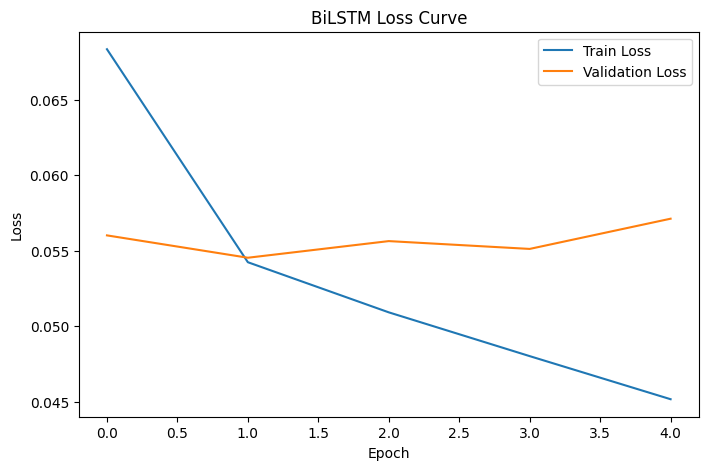

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_bilstm.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BiLSTM Loss Curve")

plt.legend()

plt.show()

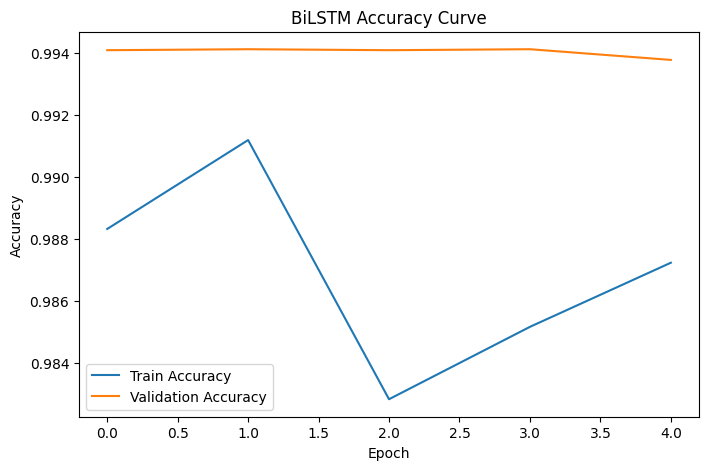

In [54]:
plt.figure(figsize=(8,5))

plt.plot(
    history_bilstm.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_bilstm.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BiLSTM Accuracy Curve")

plt.legend()

plt.show()

In [56]:
#compare
rnn_loss, rnn_acc, rnn_precision, rnn_recall = rnn_model.evaluate(
    X_test,
    y_test
)

print("RNN Accuracy :", rnn_acc)
print("BiLSTM Accuracy :", bilstm_acc)

998/998 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9941 - loss: 0.0593 - precision: 0.8028 - recall: 0.5895
RNN Accuracy : 0.9941093325614929
BiLSTM Accuracy : 0.9941093325614929


In [58]:
bilstm_model.save(
    "bilstm_toxicity.keras"
)